# Ridge, Lasso and Elastic Net Logistic Regression
## Part A — Regularisation Comparison | Part B — Shrinkage Paths

### Data assumption
The preprocessing is already completed. This notebook starts with:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train`
- `y_test`

Because `compare_regularisation()` requires validation data, 20% of the existing `X_train` is separated as validation data. The original `X_test` remains untouched for final evaluation.

### Requested placement-prediction features
`CGPA`, `AptitudeTestScore`, `Internships`, `Projects`, `SoftSkillsRating`

If preprocessing has transformed these columns, the notebook uses the actual columns present in `X_train`.


## Part A — Compare Regularisation

### Objective
Compare Ridge (L2), Lasso (L1), and Elastic Net Logistic Regression for several values of `C`.

Required output:
`C, Lasso_val_acc, Ridge_val_acc, ElasticNet_val_acc, Lasso_nonzero, Ridge_nonzero`


## 1. Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score


## 2. Load the Already-Preprocessed Files

In [9]:
# Change only these four paths
X_TRAIN_PATH = r"C:\\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\data\X_train_processed1.csv"
X_TEST_PATH  = r"C:\\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\data\X_test_processed1.csv"
Y_TRAIN_PATH = r"C:\\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\data\y_train.csv"
Y_TEST_PATH  = r"C:\\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\data\y_test.csv"

feature_cols = ["CGPA", "AptitudeTestScore", "Internships", "Projects", "SoftSkillsRating"]

X_train = pd.read_csv(X_TRAIN_PATH)
X_test  = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH)
y_test  = pd.read_csv(Y_TEST_PATH)

X_train = X_train[feature_cols]
X_test  = X_test[feature_cols]

y_train = pd.read_csv(Y_TRAIN_PATH)
y_test  = pd.read_csv(Y_TEST_PATH)

# Convert one-column target DataFrames to Series
if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]

if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (40000, 5)
X_test : (10000, 5)
y_train: (40000,)
y_test : (10000,)


In [10]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test :", X_test.isna().sum().sum())

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\nPreprocessed feature columns:")
print(list(X_train.columns))


Missing values in X_train: 0
Missing values in X_test : 0

y_train distribution:
PlacementStatus
1    26285
0    13715
Name: count, dtype: int64

y_test distribution:
PlacementStatus
1    6571
0    3429
Name: count, dtype: int64

Preprocessed feature columns:
['CGPA', 'AptitudeTestScore', 'Internships', 'Projects', 'SoftSkillsRating']


## 3. Create Validation Set from the Existing 80% Training Data

In [11]:
# Do NOT use X_test to create validation data.
# The original 20% test set remains untouched.

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model-training portion:", X_train.shape)
print("Validation portion   :", X_val.shape)
print("Untouched test set   :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


Model-training portion: (32000, 5)
Validation portion   : (8000, 5)
Untouched test set   : (10000, 5)

y_train: (32000,)
y_val  : (8000,)
y_test : (10000,)


### Final data usage

Existing 80% training data:
- 80% of it → model training = about 64% of original data
- 20% of it → validation = about 16% of original data

Existing 20% test data:
- remains untouched = 20% of original data


## 4. Define C Values

In [12]:
# C = 1 / lambda
# Smaller C -> stronger regularisation
# Larger C -> weaker regularisation

C_values = np.array([0.001, 0.01, 0.1, 1, 10, 100])

# Elastic Net mixing parameter
L1_RATIO = 0.5

print("C values:", C_values)
print("Elastic Net l1_ratio:", L1_RATIO)


C values: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
Elastic Net l1_ratio: 0.5


## 5. Implement `compare_regularisation()`

In [13]:
def compare_regularisation(    X_train, y_train,X_val,y_val, C_values, l1_ratio=0.5, zero_tol=1e-8):
    results = []

    for C in C_values:

        # Lasso: L1
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=2000,
            random_state=42
        )
        lasso.fit(X_train, y_train)
        lasso_val_acc = accuracy_score(
            y_val, lasso.predict(X_val)
        )
        lasso_nonzero = int(
            np.sum(np.abs(lasso.coef_) > zero_tol)
        )

        # Ridge: L2
        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=2000,
            random_state=42
        )
        ridge.fit(X_train, y_train)
        ridge_val_acc = accuracy_score(
            y_val, ridge.predict(X_val)
        )
        ridge_nonzero = int(
            np.sum(np.abs(ridge.coef_) > zero_tol)
        )

        # Elastic Net: L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=l1_ratio,
            solver="saga",
            max_iter=3000,
            random_state=42
        )
        elastic.fit(X_train, y_train)
        elastic_val_acc = accuracy_score(
            y_val, elastic.predict(X_val)
        )

        results.append({
            "C": C,
            "Lasso_val_acc": lasso_val_acc,
            "Ridge_val_acc": ridge_val_acc,
            "ElasticNet_val_acc": elastic_val_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)


## 6. Generate the Required Comparison DataFrame

In [14]:
results_df = compare_regularisation(
    X_train,
    y_train,
    X_val,
    y_val,
    C_values,
    l1_ratio=L1_RATIO
)

display(results_df)


c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.897125,0.899375,0.900125,4,5
1,0.010,0.900250,0.901250,0.901250,4,5
2,0.100,0.899625,0.899750,0.899750,5,5
3,1.000,0.899375,0.899625,0.899375,5,5
4,10.000,0.899375,0.899250,0.899375,5,5
5,100.000,0.899375,0.899250,0.899375,5,5


## 7. Validation Accuracy vs C

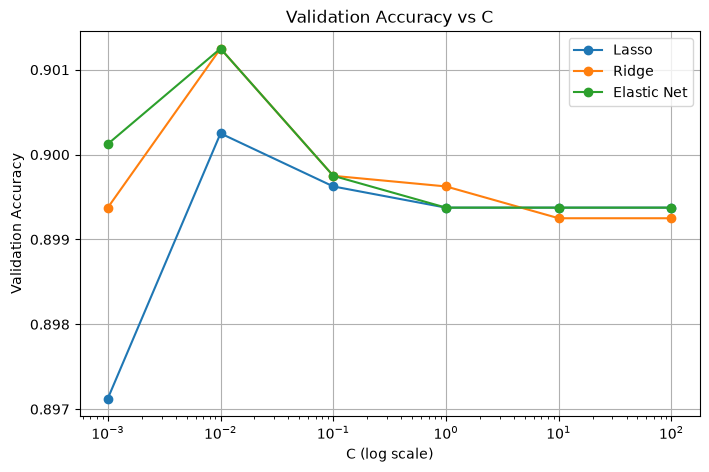

In [15]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()


## 8. Non-Zero Coefficients vs C
### This is the sparsity analysis.,As C increases, Lasso generally becomes less sparse.

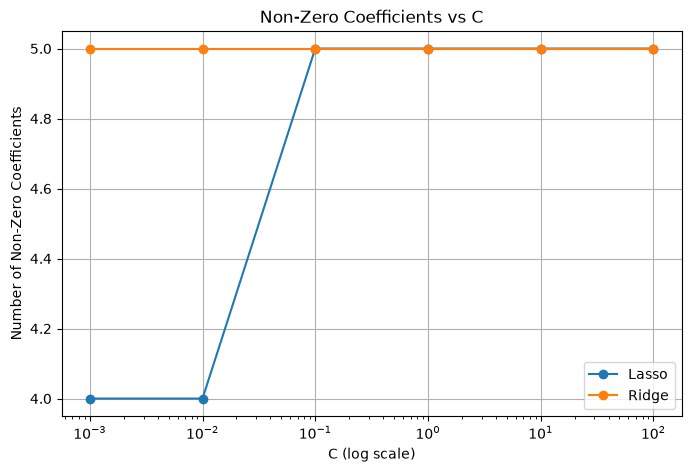

In [16]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_nonzero"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_nonzero"],
    marker="o",
    label="Ridge"
)

plt.xlabel("C (log scale)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Non-Zero Coefficients vs C")
plt.legend()
plt.grid(True)
plt.show()


## 9. Select Best C Using Validation Accuracy

In [17]:
best_lasso = results_df.loc[results_df["Lasso_val_acc"].idxmax()]
best_ridge = results_df.loc[results_df["Ridge_val_acc"].idxmax()]
best_elastic = results_df.loc[results_df["ElasticNet_val_acc"].idxmax()]

print("Best Lasso:")
display(best_lasso.to_frame().T)

print("Best Ridge:")
display(best_ridge.to_frame().T)

print("Best Elastic Net:")
display(best_elastic.to_frame().T)


Best Lasso:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
1,0.01,0.90025,0.90125,0.90125,4.0,5.0


Best Ridge:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
1,0.01,0.90025,0.90125,0.90125,4.0,5.0


Best Elastic Net:


,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
1,0.01,0.90025,0.90125,0.90125,4.0,5.0


# Part B — Shrinkage Paths

For each `C`, train Ridge, Lasso and Elastic Net and record every feature coefficient.

This shows how coefficient values change as regularisation changes.


In [18]:
feature_names = list(X_train.columns)

ridge_paths = []
lasso_paths = []
elastic_paths = []

for C in C_values:

    ridge = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=2000,
        random_state=42
    )
    ridge.fit(X_train, y_train)
    ridge_paths.append(ridge.coef_[0])

    lasso = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    )
    lasso.fit(X_train, y_train)
    lasso_paths.append(lasso.coef_[0])

    elastic = LogisticRegression(
        penalty="elasticnet",
        C=C,
        l1_ratio=L1_RATIO,
        solver="saga",
        max_iter=3000,
        random_state=42
    )
    elastic.fit(X_train, y_train)
    elastic_paths.append(elastic.coef_[0])

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)
elastic_paths = np.array(elastic_paths)

print("Number of model features:", len(feature_names))
print("Ridge path shape:", ridge_paths.shape)
print("Lasso path shape:", lasso_paths.shape)
print("Elastic Net path shape:", elastic_paths.shape)


c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penal

Number of model features: 5
Ridge path shape: (6, 5)
Lasso path shape: (6, 5)
Elastic Net path shape: (6, 5)


## 10. Ridge Shrinkage Path

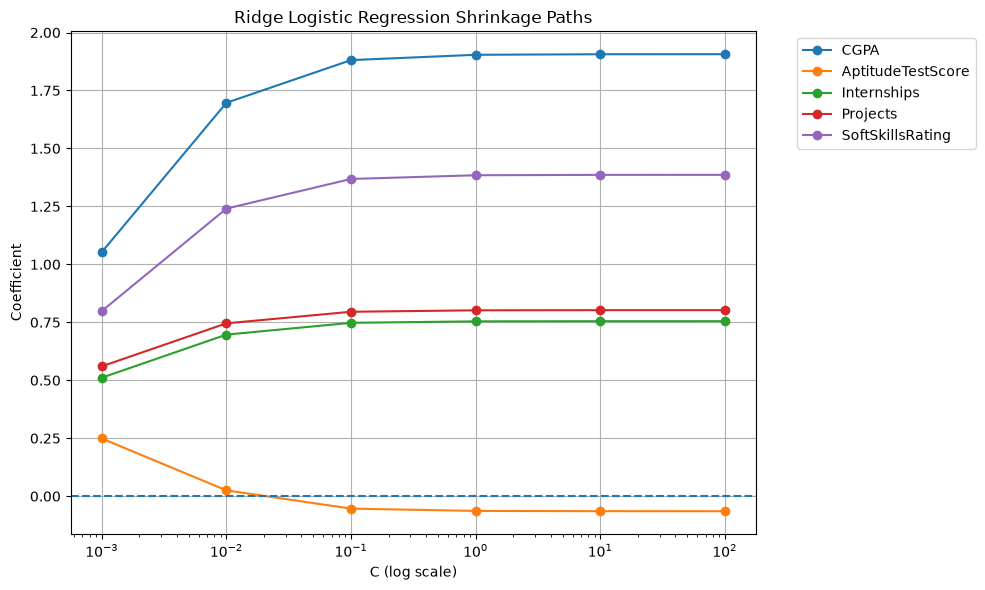

In [19]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        ridge_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title("Ridge Logistic Regression Shrinkage Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


## 11. Lasso Shrinkage Path

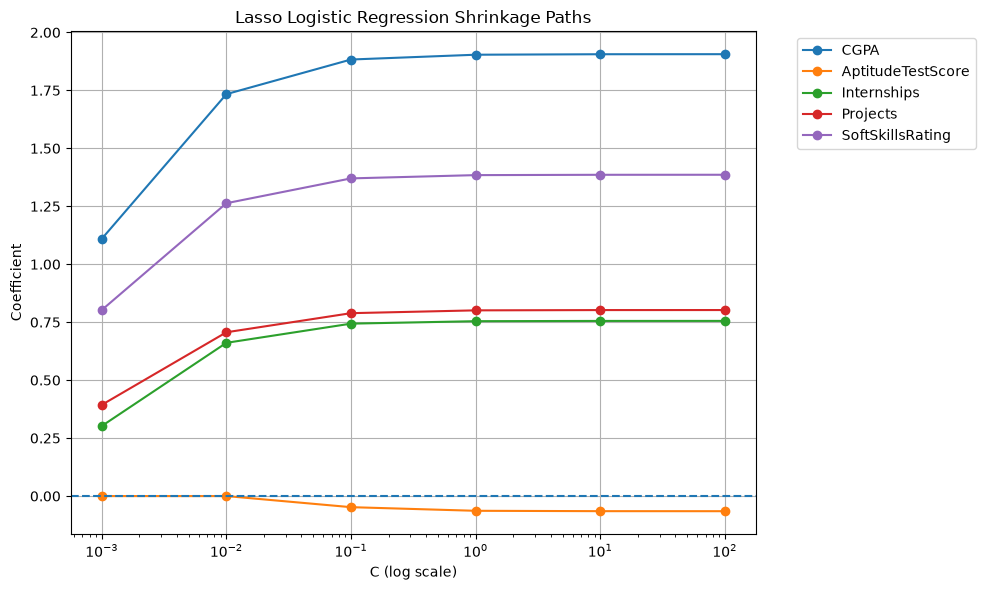

In [20]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        lasso_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title("Lasso Logistic Regression Shrinkage Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


## 12. Elastic Net Shrinkage Path

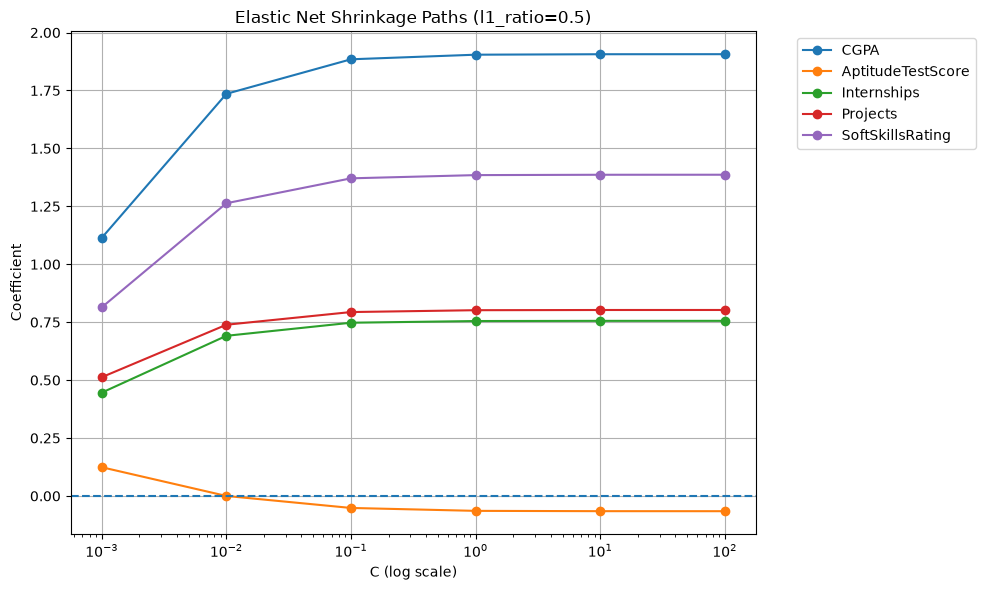

In [21]:
plt.figure(figsize=(10, 6))

for j, feature in enumerate(feature_names):
    plt.semilogx(
        C_values,
        elastic_paths[:, j],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--")
plt.xlabel("C (log scale)")
plt.ylabel("Coefficient")
plt.title(f"Elastic Net Shrinkage Paths (l1_ratio={L1_RATIO})")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


## 13. Coefficient Comparison at Best C

In [22]:
best_C_lasso = float(best_lasso["C"])
best_C_ridge = float(best_ridge["C"])
best_C_elastic = float(best_elastic["C"])

lasso_best = LogisticRegression(
    penalty="l1",
    C=best_C_lasso,
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
lasso_best.fit(X_train, y_train)

ridge_best = LogisticRegression(
    penalty="l2",
    C=best_C_ridge,
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)
ridge_best.fit(X_train, y_train)

elastic_best = LogisticRegression(
    penalty="elasticnet",
    C=best_C_elastic,
    l1_ratio=L1_RATIO,
    solver="saga",
    max_iter=3000,
    random_state=42
)
elastic_best.fit(X_train, y_train)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Ridge": ridge_best.coef_[0],
    "Lasso": lasso_best.coef_[0],
    "ElasticNet": elastic_best.coef_[0]
})

display(coefficient_table)


c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\vippa\OneDrive\Desktop\KLH\ML\Placement Prediction\.MLvenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning

,Feature,Ridge,Lasso,ElasticNet
0,CGPA,1.696907,1.733759,1.735493
1,AptitudeTestScore,0.025144,0.000000,0.000000
2,Internships,0.696950,0.661014,0.691208
3,Projects,0.745634,0.706529,0.739000
4,SoftSkillsRating,1.240453,1.263219,1.263370


## 14. Final Test Evaluation

The 20% test set was not used during `C` selection. Now evaluate the selected model once on `X_test`.

The model with the highest validation accuracy is selected.


In [23]:
best_candidates = {
    "Lasso": (best_C_lasso, float(best_lasso["Lasso_val_acc"])),
    "Ridge": (best_C_ridge, float(best_ridge["Ridge_val_acc"])),
    "ElasticNet": (best_C_elastic, float(best_elastic["ElasticNet_val_acc"]))
}

best_method = max(
    best_candidates,
    key=lambda name: best_candidates[name][1]
)

if best_method == "Lasso":
    final_model = lasso_best
elif best_method == "Ridge":
    final_model = ridge_best
else:
    final_model = elastic_best

y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Selected model:", best_method)
print("Selected C:", best_candidates[best_method][0])
print("Validation accuracy:", best_candidates[best_method][1])
print("Final test accuracy:", test_accuracy)


Selected model: Ridge
Selected C: 0.01
Validation accuracy: 0.90125
Final test accuracy: 0.895


# Practical Conclusion

### Part A — Regularisation comparison
- Implement `compare_regularisation()`.
- Compare Ridge, Lasso and Elastic Net across different `C` values.
- Compare validation accuracy.
- Compare non-zero coefficient counts.
- Select the best model and `C` using validation performance.

### Part B — Shrinkage paths
- Plot Ridge coefficient paths.
- Plot Lasso coefficient paths.
- Plot Elastic Net coefficient paths.
- Explain how stronger regularisation shrinks coefficients.
- Explain why Lasso can produce zero coefficients.

### Final evaluation
Use the untouched 20% test set only after model and `C` selection.
